In [1]:
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as qda
from mlxtend.plotting import plot_decision_regions

plt.style.use('ggplot')
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)
pd.options.mode.chained_assignment = None

In [2]:
df = pd.read_csv('Sleepdataset.csv')
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)

<ArrowStringArray>
[              'Person ID',                     'Age',
          'Sleep Duration',        'Quality of Sleep',
 'Physical Activity Level',            'Stress Level',
              'Heart Rate',             'Daily Steps']
Length: 8, dtype: str


In [4]:
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

<ArrowStringArray>
['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
Length: 5, dtype: str


In [5]:
df1=df
df1 = df1.drop(['Person ID'], axis=1)
df1[['Systolic_BP', 'Diastolic_BP']] = df1['Blood Pressure'].str.split('/', expand=True).astype(int)
df1 = df1.drop(['Blood Pressure'], axis=1)


In [6]:
for col in df1.columns:
    pct_missing = np.mean(df1[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Gender - 0%
Age - 0%
Occupation - 0%
Sleep Duration - 0%
Quality of Sleep - 0%
Physical Activity Level - 0%
Stress Level - 0%
BMI Category - 0%
Heart Rate - 0%
Daily Steps - 0%
Sleep Disorder - 59%
Systolic_BP - 0%
Diastolic_BP - 0%


In [7]:
df1['Sleep Disorder'] = df1['Sleep Disorder'].fillna('No Disorder')
df1

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [8]:
df1.isnull().values.any()

np.False_

In [9]:
stats_all = df1.describe(include=[np.number]).T
stats_all

,count,mean,std,min,25%,50%,75%,max
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.8,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.0,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.0,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.0,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.0,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.0,10000.0
Systolic_BP,374.0,128.553476,7.748118,115.0,125.00,130.0,135.0,142.0
Diastolic_BP,374.0,84.649733,6.161611,75.0,80.00,85.0,90.0,95.0


In [10]:
for col in df1.columns:
    pct_missing = np.mean(df1[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Gender - 0%
Age - 0%
Occupation - 0%
Sleep Duration - 0%
Quality of Sleep - 0%
Physical Activity Level - 0%
Stress Level - 0%
BMI Category - 0%
Heart Rate - 0%
Daily Steps - 0%
Sleep Disorder - 0%
Systolic_BP - 0%
Diastolic_BP - 0%


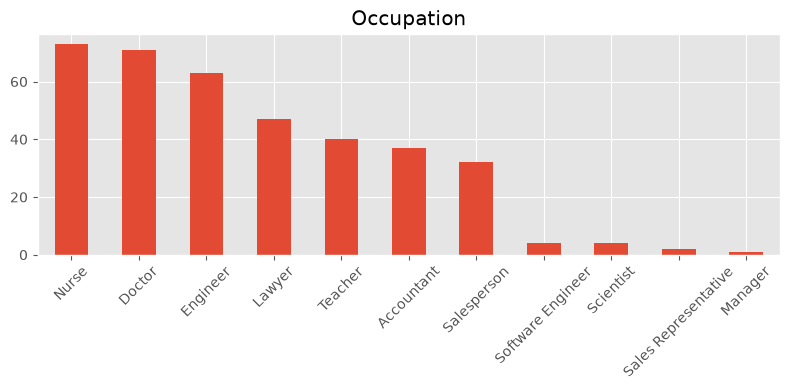

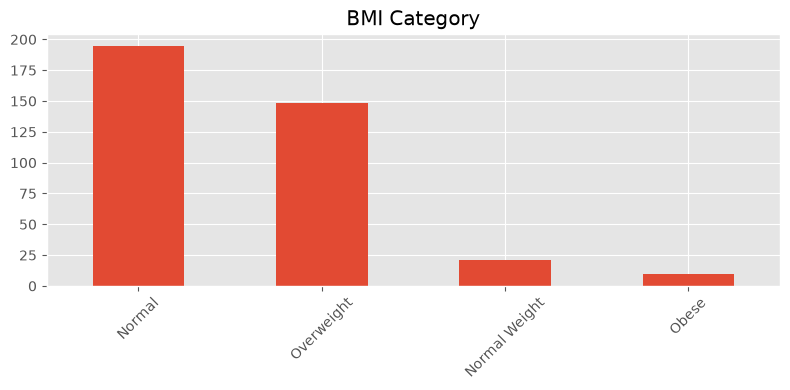

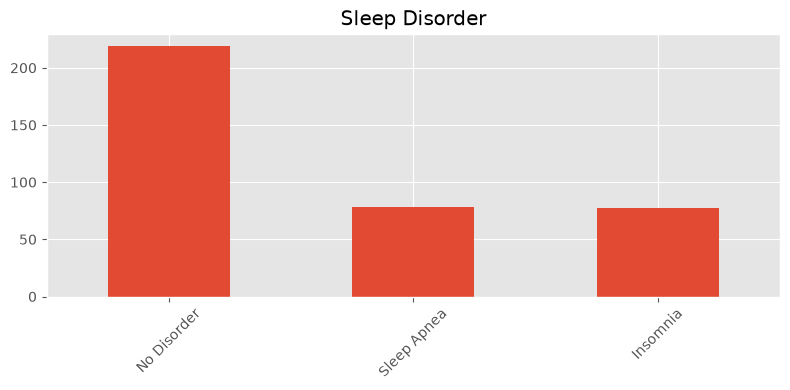

In [11]:
cat_cols = ['Occupation', 'BMI Category', 'Sleep Disorder']
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df1[col].value_counts().plot.bar()
    plt.title(col)
    plt.xlabel('')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='BMI Category'>

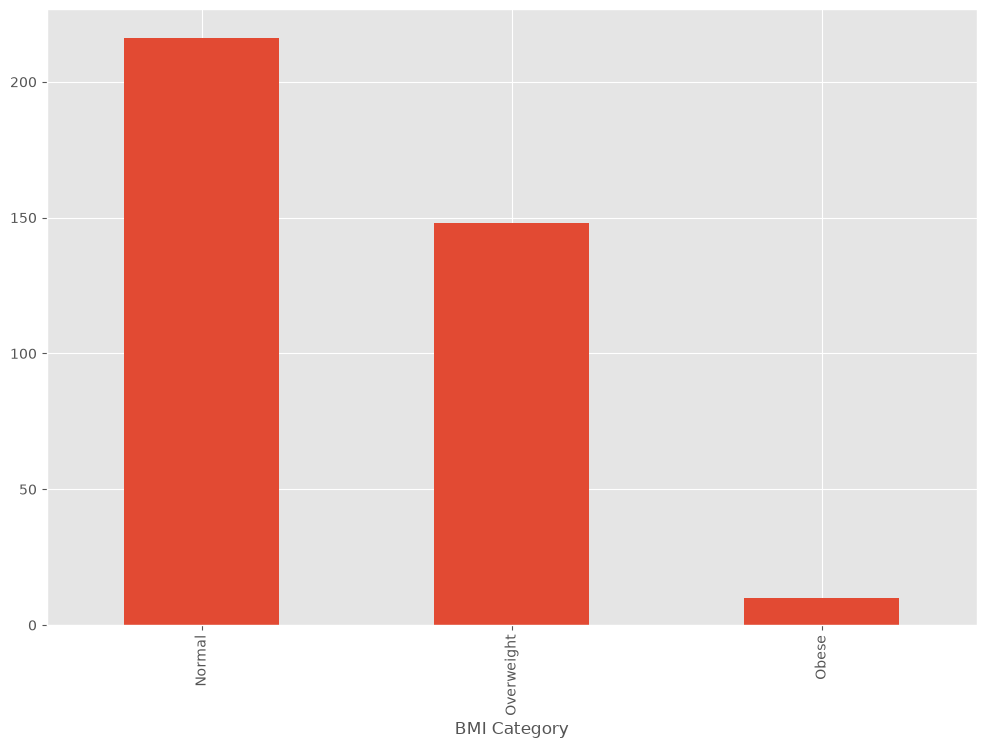

In [12]:
df1['BMI Category'] = df1['BMI Category'].replace('Normal Weight', 'Normal')
df1['BMI Category'].value_counts().plot.bar()

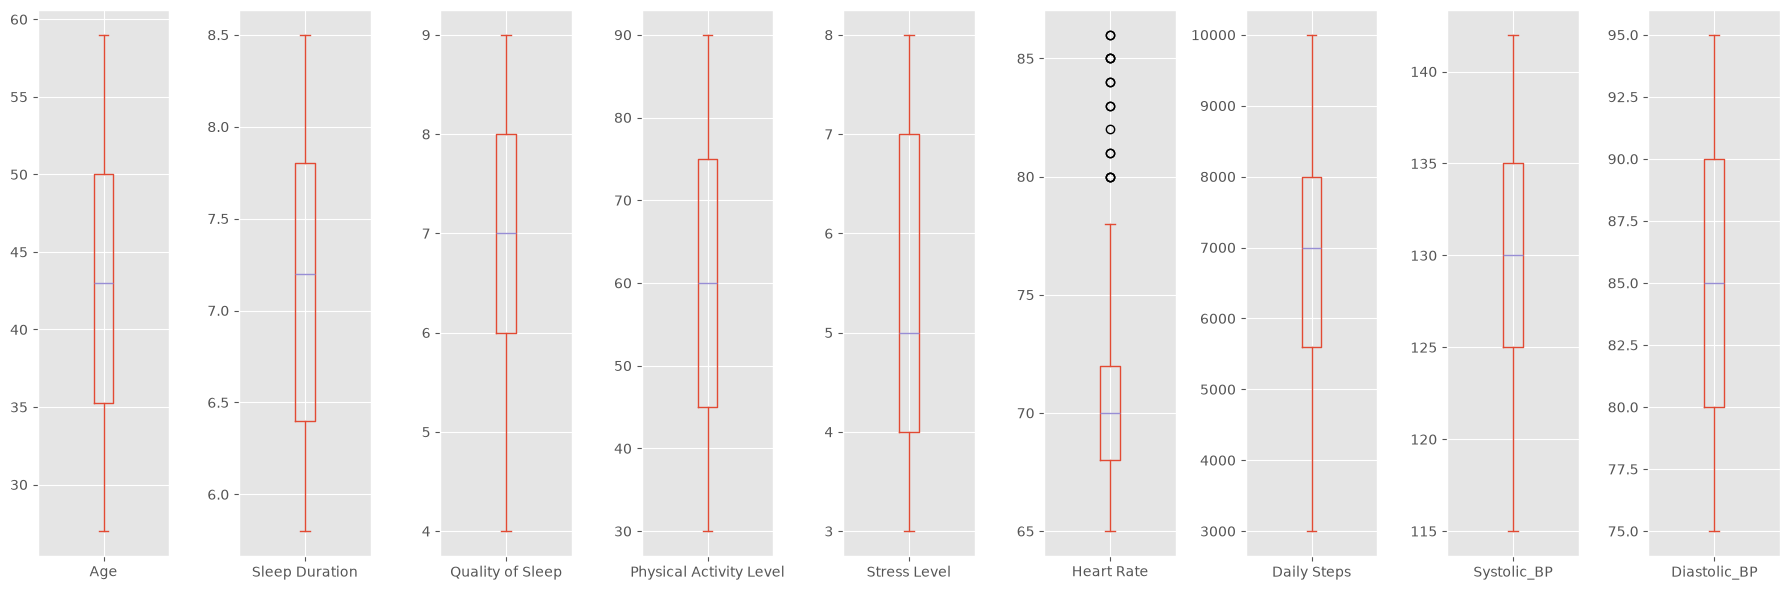

In [13]:
df_numeric = df1.select_dtypes(include=[np.number])

num_cols_count = len(df_numeric.columns)

df_numeric.plot(kind='box', subplots=True, layout=(1, num_cols_count),
                figsize=(num_cols_count*2, 6))
plt.tight_layout()
plt.show()

Нижняя граница: 65.0
Верхняя граница: 78.0


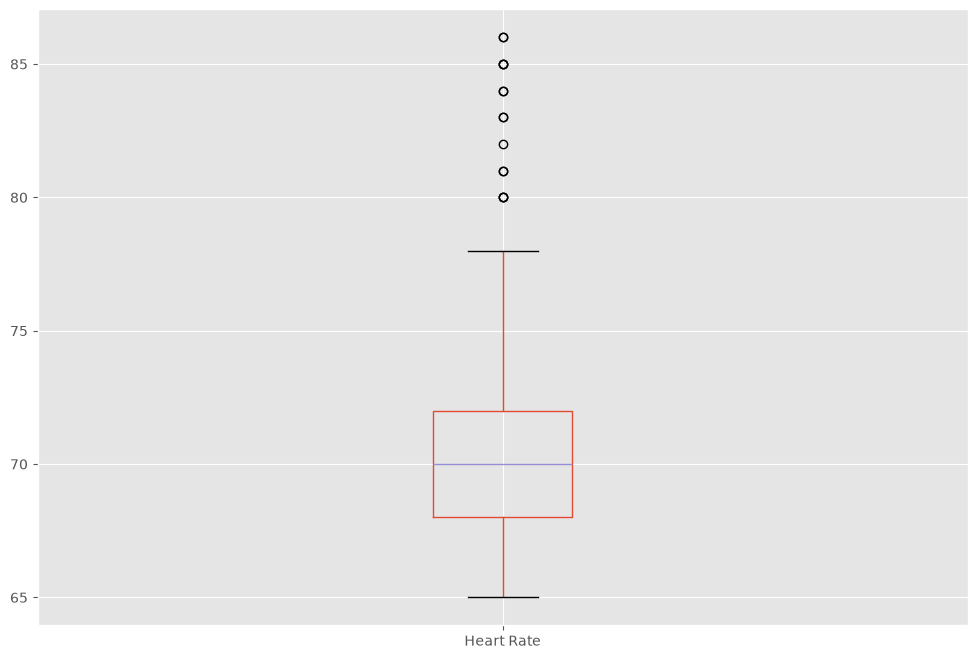

In [14]:
result = df1.boxplot(column=['Heart Rate'], return_type='dict')

lower_whisker = result['whiskers'][0].get_ydata()[1]
upper_whisker = result['whiskers'][1].get_ydata()[1]

print(f"Нижняя граница: {lower_whisker}")
print(f"Верхняя граница: {upper_whisker}")

In [15]:
numeric_cols = df1.select_dtypes(include=[np.number]).columns

In [16]:
df1 = df1[df1['Heart Rate'] <= 78]
df1 = df1[df1['Sleep Duration'] <= 10.0]

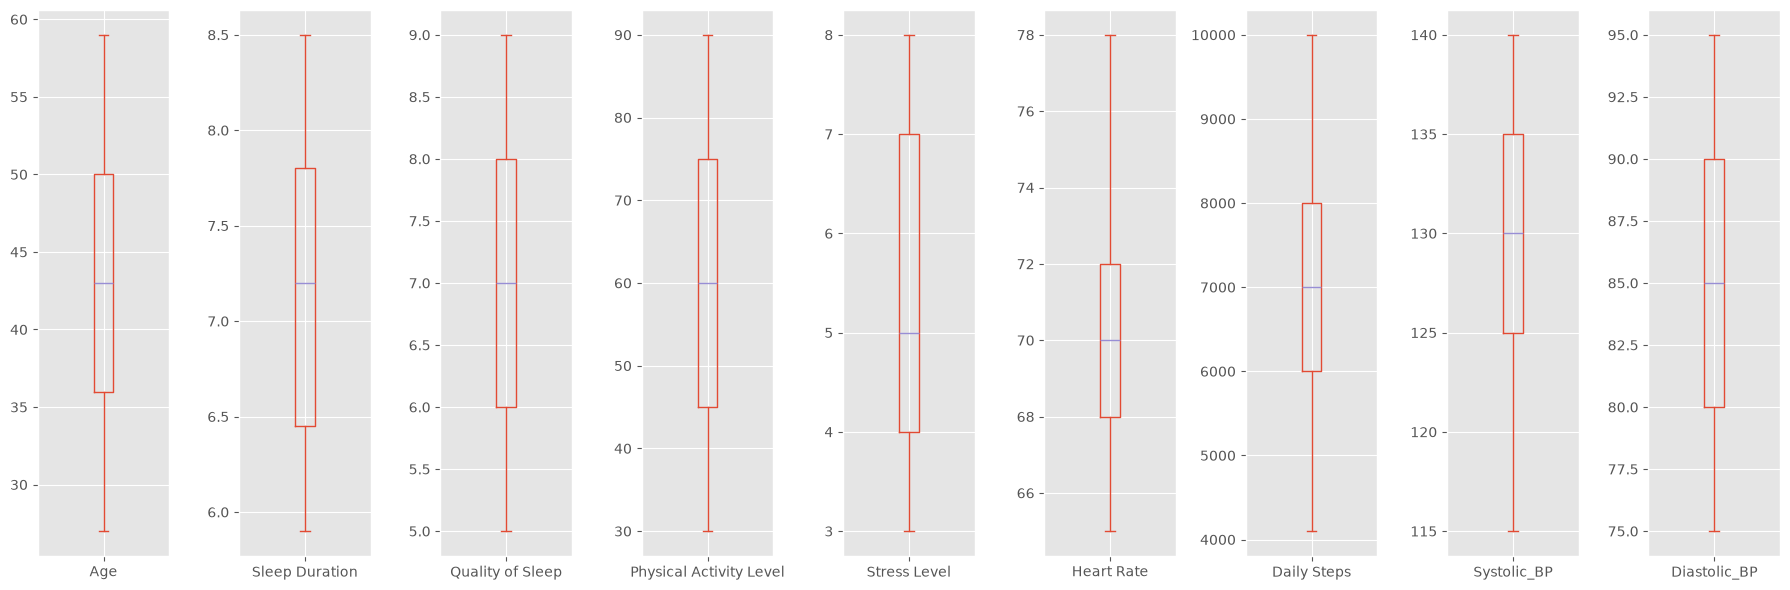

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
7,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No Disorder,120,80
8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No Disorder,120,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [17]:
df_numeric = df1.select_dtypes(include=[np.number])
num_cols_count = len(df_numeric.columns)

df_numeric.plot(kind='box', subplots=True, layout=(1, num_cols_count),
                figsize=(num_cols_count*2, 6))
plt.tight_layout()
plt.show()
df1

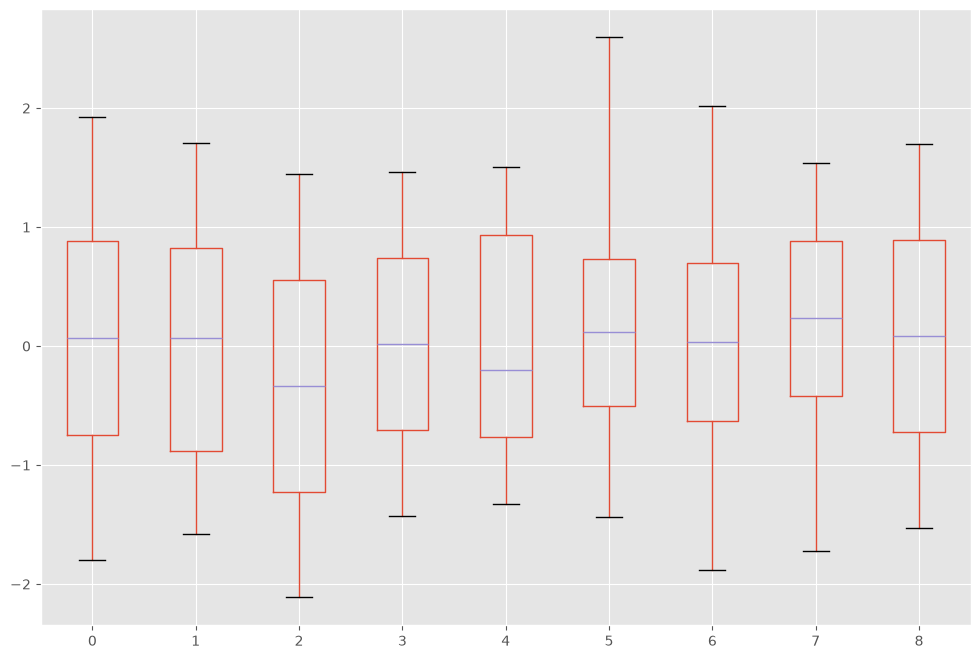

In [18]:
scaler = StandardScaler()
data_11 = pd.DataFrame (scaler.fit_transform(df_numeric))
boxplot = data_11.boxplot()

In [19]:
stats_all = data_11.describe()
stats_all

,0,1,2,3,4,5,6,7,8
count,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02
mean,7.916911e-17,6.234567e-16,2.572996e-16,4.205859e-17,-4.948069e-17,-9.203409e-16,1.707084e-16,9.896138e-16,-3.958455e-17
std,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00
min,-1.794529e+00,-1.582083e+00,-2.112331e+00,-1.425013e+00,-1.330948e+00,-1.434762e+00,-1.882518e+00,-1.723005e+00,-1.526902e+00
25%,-7.477475e-01,-8.857338e-01,-1.223320e+00,-7.028511e-01,-7.641506e-01,-5.050157e-01,-6.257248e-01,-4.191291e-01,-7.205504e-01
50%,6.641605e-02,6.383349e-02,-3.343080e-01,1.931131e-02,-1.973530e-01,1.148155e-01,3.574517e-02,2.328091e-01,8.580121e-02
75%,8.805796e-01,8.234873e-01,5.547036e-01,7.414737e-01,9.362424e-01,7.346467e-01,6.972152e-01,8.847473e-01,8.921529e-01
max,1.927361e+00,1.709750e+00,1.443715e+00,1.463636e+00,1.503040e+00,2.594140e+00,2.020155e+00,1.536685e+00,1.698505e+00


In [20]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df1['Sleep Disorder'])

features = ['Heart Rate','Daily Steps', 'Quality of Sleep', 'Physical Activity Level']
X_clustering = df1[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)
print(X_train)


     Heart Rate  Daily Steps  Quality of Sleep  Physical Activity Level
278    1.664394     2.020155         -1.223320                 1.463636
118   -0.505016     0.035745          0.554704                 0.019311
31     0.114816     0.697215         -0.334308                 0.741474
36     0.114816     0.697215         -0.334308                 0.741474
153   -0.505016     0.697215          0.554704                 1.463636
..          ...          ...               ...                      ...
71     0.734647    -1.287195         -1.223320                -1.425013
106   -0.505016     0.035745          0.554704                 0.019311
270    1.664394     2.020155         -1.223320                 1.463636
348   -0.505016     0.035745          1.443715                 0.741474
102   -0.505016     0.697215          0.554704                 0.019311

[240 rows x 4 columns]


In [21]:
class KohonenNet():
    def __init__(self, m=3, n=3, lr=1, sigma=1, max_iter=3000, weights = []):
        self.m = m #количество классов
        self.n = n #количество уровней сети
        self.shape = (m, n)
        self.initial_lr = lr
        self.lr = lr #скорость обучения
        self.sigma = sigma #параметр изменения скорости обучения (она будет снижаться с каждой итерацией)
        self.max_iter = max_iter

        self.weights = weights

#функция нахождения выйгравшего нейрона (нейрона с минимальным расстоянием до точки)
    def _find_bmu(self, x):
        x_stack = np.stack([x]*(self.m*self.n), axis=0)#матрица размером [количество центров кластеров(нейронов), количество признаков] (для каждого веса своя строка признаков(точка))
        distance = np.linalg.norm(x_stack - self.weights, axis=1)#эвклидовы расстояния между точкой выборки и нейронами
        return np.argmin(distance)#возвращаем индекс минимального расстояния (индекс подходящего нейрона)

    def step(self, x):
        x_stack = np.stack([x]*(self.m*self.n), axis=0)#матрица размером [количество весов, количество признаков] (для каждого веса своя строка признаков(точка))

        bmu_index = self._find_bmu(x)#передаем в функцию строку признаков (точку) и получаем индекс выйгравшего нейрона (центра кластера)
        self.weights[bmu_index] += self.lr * (x - self.weights[bmu_index])

    #обучение весов
    def fit(self, X, epochs=1, shuffle=True):
        global_iter_counter = 0
        n_samples = X.shape[0]#количество элементов выборки
        total_iterations = np.minimum(epochs * n_samples, self.max_iter)#количество обучения весов в эпохе

        for epoch in range(epochs):#изначально у нас 1 эпоха
            if global_iter_counter > self.max_iter:#не даем проводить больше 3000 эпох
                break

            if shuffle:
                indices = np.random.permutation(n_samples)#создание массива с индексами в разброс
            else:
                indices = np.arange(n_samples)#создание массива с индексами по порядку

            #обучение
            for idx in indices:#проход по выборке с индексами idx
                if global_iter_counter > self.max_iter:
                    break
                input = X[idx]
                #перемещение нейрона(изменение весов победившего нейрона)
                self.step(input)

                global_iter_counter += 1
                self.lr = (1 - (global_iter_counter / total_iterations)) * self.initial_lr#изменение параметра обучения

        self._n_iter_ = global_iter_counter

        return

    def returnChangedWeights(self):
      return self.weights

    def predict(self, X):
        labels = np.array([self._find_bmu(x) for x in X])
        return labels


In [22]:
weights = np.random.uniform(
    0.4,
    0.6,
    size=(3, 4)
)

net = KohonenNet(m=3, n=1, weights=weights)
net.fit(X_train.values, shuffle=True)

result_train = net.predict(X_train.values)

result_test = net.predict(X_test.values)

In [23]:
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=X_test.iloc[:, 0],
        y=X_test.iloc[:, 1],
        z=X_test.iloc[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=result_test
        ),
        name='Тестовые объекты'
    )
)

changed_weights = net.returnChangedWeights()

fig.add_trace(
    go.Scatter3d(
        x=changed_weights[:, 0],
        y=changed_weights[:, 1],
        z=changed_weights[:, 2],
        mode='markers',
        marker=dict(
            size=8,
            color='red',
            symbol='diamond'
        ),
        name='Нейроны'
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title='Признак 1',
        yaxis_title='Признак 2',
        zaxis_title='Признак 3'
    ),
    title='Результат кластеризации тестовой выборки сетью Кохонена'
)

fig.show()

In [24]:
from mlxtend.evaluate import confusion_matrix
from sklearn.metrics import classification_report

print("Матрица ошибок для обучающей выборки:")
print(confusion_matrix(y_train, result_train))

print("\nClassification Report для обучающей выборки:")
print(classification_report(y_train, result_train))

print("Матрица ошибок для тестовой выборки:")
print(confusion_matrix(y_test, result_test))

print("\nClassification Report для тестовой выборки:")
print(classification_report(y_test, result_test))

Матрица ошибок для обучающей выборки:
[[  1  29  23]
 [  2  28 109]
 [ 24   2  22]]

Classification Report для обучающей выборки:
              precision    recall  f1-score   support

           0       0.04      0.02      0.03        53
           1       0.47      0.20      0.28       139
           2       0.14      0.46      0.22        48

    accuracy                           0.21       240
   macro avg       0.22      0.23      0.18       240
weighted avg       0.31      0.21      0.21       240

Матрица ошибок для тестовой выборки:
[[ 0 12  6]
 [ 2 15 63]
 [ 5  4 12]]

Classification Report для тестовой выборки:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.48      0.19      0.27        80
           2       0.15      0.57      0.24        21

    accuracy                           0.23       119
   macro avg       0.21      0.25      0.17       119
weighted avg       0.35      0.23      0.22 

kmeans, pnn, mlp на реальном а также раннюю остановку через реализацию библиотек только на реальном, сраниваем по матрцие ошибок, по времени, по количеству эпох
ранняя остановка на библиотечных сетях, dropout тоже
есть ли на валидационной выборке лос функция растет то пора остановаиться, loss функция = ошибка, это график с двумя полосами одна трейн где на трейн она падает а на валидации она начинает расти и поэтому мы говорим какая точка оптимальная, сохранить лучших весов в файл на млп, можно историю сохранять в файл и оптом загрузить!!! Лосс, обучение,
как меняется график лосс функции, и точности например(можно еще оценку взять на выбор, что то еще типа), посмотреть как на трех выборках действует,
у пнн нет эпох но есть слой большой(функция)

In [25]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_train)
df_cluster_centers = pd.DataFrame(kmeans.cluster_centers_)
print(df_cluster_centers)

print("Матрица ошибок для обучающей выборки:")
print(confusion_matrix(y_train, kmeans.labels_))

print("\nClassification Report для обучающей выборки:")
print(classification_report(y_train, kmeans.labels_))

print("Матрица ошибок для тестовой выборки:")
print(confusion_matrix(y_test, kmeans.predict(X_test)))

print("\nClassification Report для тестовой выборки:")
print(classification_report(y_test, kmeans.predict(X_test)))


          0         1         2         3
0 -1.434762 -0.948768  0.472005 -0.988357
1  0.125884  0.734541  0.237199  0.767265
2  0.837952 -0.802117 -1.082949 -0.969756
Матрица ошибок для обучающей выборки:
[[20  6 27]
 [23 88 28]
 [ 0 46  2]]

Classification Report для обучающей выборки:
              precision    recall  f1-score   support

           0       0.47      0.38      0.42        53
           1       0.63      0.63      0.63       139
           2       0.04      0.04      0.04        48

    accuracy                           0.46       240
   macro avg       0.38      0.35      0.36       240
weighted avg       0.47      0.46      0.46       240

Матрица ошибок для тестовой выборки:
[[ 6  0 12]
 [17 48 15]
 [ 0 17  4]]

Classification Report для тестовой выборки:
              precision    recall  f1-score   support

           0       0.26      0.33      0.29        18
           1       0.74      0.60      0.66        80
           2       0.13      0.19      0.15     

In [26]:
import math


# Probabilistic Neural Network with 4 layers
class PNN(object):
    def __init__(self):
        self.L2 = []  # Layer 2 that holds the patterns
        print('Empty PNN created.')

    def train(self, X, y, p=4):
        self.n_ = X.shape[1]  # num of features
        self.p_ = p  # num of classes

        # Layer 2 (Pattern): Set up empty lists for each class

        for k in range(self.p_):
            self.L2.append([])  # Using Python's basic lists because ndarray cannot append empty arrays
            # Also perhaps we might have to input different data types

        # Enter patterns into Layer 2
        for i in range(X.shape[0]):
            self.L2[y[i]].append(X[i])

        self.L2 = np.array(self.L2, dtype=object)  # Change to ndarray for speed (Is this faster?)

        print('PNN with %d classes trained.' % self.p_)

    def crossValidate(self, X, y, sigma=0.5):
        result = self.predict(X, sigma)
        num_correct = sum(result[:, 0] == y)

        print('Cross validation accuracy with sigma %.2f: %.1f%%' % (sigma, num_correct / len(y) * 100))

    def predict(self, X, sigma=0.5):
        m = X.shape[0]
        accL3 = np.zeros((m, self.p_))
        accL4 = np.zeros(m)

        self.sigma_ = sigma  # smoothing parameter, not standard deviation
        self.C1_ = 2 * self.sigma_ ** 2
        C2_ = (math.sqrt(2 * math.pi) * self.sigma_) ** (- self.n_)

        # Layer 1 (Input): x
        for i in range(m):
            x = X[i]

            # Layer 3 (Averaging): for each class
            self.L3_ = np.zeros(self.p_)
            for k in range(self.p_):
                for ki in range(len(self.L2[k])):
                    self.L3_[k] += self._activation(x, self.L2[k][ki])
                self.L3_[k] /= len(self.L2[k])

                # Multiply constant
                self.L3_[k] *= C2_
                accL3[i][k] = self.L3_[k]

            # Layer 4 (Output/Decision): Maxing
            self.L4_ = self.L3_.argmax()
            accL4[i] = self.L4_

        return np.column_stack((accL4, accL3))

    def _activation(self, x, w):
        diff = x - w
        return math.exp(- np.dot(diff, diff) / self.C1_)


# Normalize to unit length: [0, 1]
# X must be ndarray
def Normalize(X):
    x_max = X.max(axis=0)
    x_min = X.min(axis=0)
    return (X - x_min) / (x_max - x_min)


#from neupy import algorithms

X_train_pnn = np.asarray(X_train)
y_train_pnn = np.asarray(y_train)

X_test_pnn = np.asarray(X_test)
y_test_pnn = np.asarray(y_test)

pnn = PNN()

pnn.train(
    X_train_pnn,
    y_train_pnn,
    p=3
)

prY_Train = pnn.predict(
    X_train_pnn,
    sigma=0.5
)

prY_Test = pnn.predict(
    X_test_pnn,
    sigma=0.5
)

pred_train = prY_Train[:, 0].astype(int)
pred_test = prY_Test[:, 0].astype(int)

print("Матрица ошибок для обучающей выборки:")
print(confusion_matrix(y_train, pred_train))

print("\nClassification Report для обучающей выборки:")
print(classification_report(y_train, pred_train))

print("Матрица ошибок для тестовой выборки:")
print(confusion_matrix(y_test, pred_test))

print("\nClassification Report для тестовой выборки:")
print(classification_report(y_test, pred_test))


Empty PNN created.
PNN with 3 classes trained.
Матрица ошибок для обучающей выборки:
[[ 46   6   1]
 [  8 127   4]
 [  0   5  43]]

Classification Report для обучающей выборки:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        53
           1       0.92      0.91      0.92       139
           2       0.90      0.90      0.90        48

    accuracy                           0.90       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.90      0.90      0.90       240

Матрица ошибок для тестовой выборки:
[[16  2  0]
 [ 6 71  3]
 [ 2  1 18]]

Classification Report для тестовой выборки:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76        18
           1       0.96      0.89      0.92        80
           2       0.86      0.86      0.86        21

    accuracy                           0.88       119
   macro avg       0.83      0.88      0.85       1

In [27]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

X_train_tf = np.asarray(X_train, dtype=np.float32)
X_test_tf = np.asarray(X_test, dtype=np.float32)
y_train_tf = np.asarray(y_train, dtype=np.int32)
y_test_tf = np.asarray(y_test, dtype=np.int32)

model_tf = Sequential([
    Input(shape=(4,)),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_tf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tf.summary()

early_stopping_tf = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_tf = model_tf.fit(
    X_train_tf,
    y_train_tf,
    epochs=600,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_tf],
    verbose=0
)

print("Количество эпох обучения:", len(history_tf.history['loss']))
pred_train_tf = np.argmax(
    model_tf.predict(X_train, verbose=0),
    axis=1
)

pred_test_tf = np.argmax(
    model_tf.predict(X_test, verbose=0),
    axis=1
)

print("Матрица ошибок — TensorFlow MLP — Train:")
print(confusion_matrix(y_train, pred_train_tf))

print("\nClassification Report — TensorFlow MLP — Train:")
print(classification_report(y_train, pred_train_tf))

print("\nМатрица ошибок — TensorFlow MLP — Test:")
print(confusion_matrix(y_test, pred_test_tf))

print("\nClassification Report — TensorFlow MLP — Test:")
print(classification_report(y_test, pred_test_tf))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

Количество эпох обучения: 384
Матрица ошибок — TensorFlow MLP — Train:
[[ 40  12   1]
 [  3 131   5]
 [  0   7  41]]

Classification Report — TensorFlow MLP — Train:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83        53
           1       0.87      0.94      0.91       139
           2       0.87      0.85      0.86        48

    accuracy                           0.88       240
   macro avg       0.89      0.85      0.87       240
weighted avg       0.89      0.88      0.88       240


Матрица ошибок — TensorFlow MLP — Test:
[[15  3  0]
 [ 2 76  2]
 [ 2  3 16]]

Classification Report — TensorFlow MLP — Test:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        18
           1       0.93      0.95      0.94        80
           2       0.89      0.76      0.82        21

    accuracy                           0.90       119
   macro avg       0.87      0.85      0.86       119
w

In [28]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=history_tf.history['loss'],
        mode='lines',
        name='Обучающая выборка'
    )
)

fig.add_trace(
    go.Scatter(
        y=history_tf.history['val_loss'],
        mode='lines',
        name='Валидационная выборка'
    )
)

fig.update_layout(
    title='Изменение функции ошибки при обучении MLP TensorFlow',
    xaxis_title='Эпоха',
    yaxis_title='Loss'
)

fig.show()

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)


class MLP_PyTorch(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.network(x)


def predict_torch(model, X):
    model.eval()

    with torch.no_grad():
        output = model(X)
        prediction = torch.argmax(output, dim=1)

    return prediction.numpy()


X_train_torch = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test_torch = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train_torch = torch.tensor(
    np.asarray(y_train),
    dtype=torch.long
)

y_test_torch = torch.tensor(
    np.asarray(y_test),
    dtype=torch.long
)

model_torch = MLP_PyTorch()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_torch.parameters(),
    lr=0.001
)

X_train_torch_part, X_val_torch, y_train_torch_part, y_val_torch = train_test_split(
    X_train_torch,
    y_train_torch,
    test_size=0.2,
    random_state=42,
    stratify=y_train_torch
)
max_epochs = 600
patience = 20

best_val_loss = float('inf')
best_model = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(max_epochs):

    # Режим обучения
    model_torch.train()

    optimizer.zero_grad()

    output = model_torch(X_train_torch_part)
    loss = criterion(output, y_train_torch_part)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Режим проверки
    model_torch.eval()

    with torch.no_grad():
        val_output = model_torch(X_val_torch)
        val_loss = criterion(val_output, y_val_torch)

    val_losses.append(val_loss.item())

    # Early Stopping
    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_model = {
            key: value.clone()
            for key, value in model_torch.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping на эпохе:", epoch + 1)
        break

# Возвращаем лучшие веса
model_torch.load_state_dict(best_model)

best_epoch = np.argmin(val_losses)

print("Оптимальная эпоха:", best_epoch + 1)
print("Минимальный Validation Loss:", val_losses[best_epoch])
print("Train Loss в оптимальной точке:", train_losses[best_epoch])

print("Количество эпох обучения:", len(train_losses))
X_train_torch_full = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

y_train_torch_full = torch.tensor(
    np.asarray(y_train),
    dtype=torch.long
)

pred_train_torch = predict_torch(
    model_torch,
    X_train_torch
)

pred_test_torch = predict_torch(
    model_torch,
    X_test_torch
)

print("Матрица ошибок — PyTorch MLP — Train:")
print(confusion_matrix(y_train, pred_train_torch))

print("\nClassification Report — PyTorch MLP — Train:")
print(classification_report(y_train, pred_train_torch))

print("\nМатрица ошибок — PyTorch MLP — Test:")
print(confusion_matrix(y_test, pred_test_torch))

print("\nClassification Report — PyTorch MLP — Test:")
print(classification_report(y_test, pred_test_torch))

Early stopping на эпохе: 445
Оптимальная эпоха: 425
Минимальный Validation Loss: 0.7788254618644714
Train Loss в оптимальной точке: 0.5299481153488159
Количество эпох обучения: 445
Матрица ошибок — PyTorch MLP — Train:
[[ 40  12   1]
 [  3 134   2]
 [  0  24  24]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83        53
           1       0.79      0.96      0.87       139
           2       0.89      0.50      0.64        48

    accuracy                           0.82       240
   macro avg       0.87      0.74      0.78       240
weighted avg       0.84      0.82      0.81       240


Матрица ошибок — PyTorch MLP — Test:
[[15  3  0]
 [ 2 76  2]
 [ 2 14  5]]

Classification Report — PyTorch MLP — Test:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        18
           1       0.82      0.95      0.88        80
           2       0.71  

In [30]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=train_losses,
        mode='lines',
        name='Обучающая выборка'
    )
)

fig.add_trace(
    go.Scatter(
        y=val_losses,
        mode='lines',
        name='Валидационная выборка'
    )
)

fig.update_layout(
    title='Изменение функции ошибки при обучении MLP PyTorch',
    xaxis_title='Эпоха',
    yaxis_title='Loss'
)

fig.show()